In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("top_insta_influencers_data.csv")
df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


In [3]:
df.columns

Index(['rank', 'channel_info', 'influence_score', 'posts', 'followers',
       'avg_likes', '60_day_eng_rate', 'new_post_avg_like', 'total_likes',
       'country'],
      dtype='object')

In [4]:
def convert_to_number(x):
    if isinstance(x, str):
        x = x.replace(",", "").lower()
        if "m" in x:
            return float(x.replace("m", "")) * 1e6
        elif "k" in x:
            return float(x.replace("k", "")) * 1e3
        elif "b" in x:
            return float(x.replace("b", "")) * 1e9
        elif "%" in x:
            return float(x.replace("%", "")) / 100
    return x


In [5]:
cols = ["followers", "avg_likes", "new_post_avg_like", "total_likes", "60_day_eng_rate"]

for col in cols:
    df[col] = df[col].apply(convert_to_number)
    

In [6]:
df["total_engagement"] = df["avg_likes"]
df["engagement_per_follower"] = df["avg_likes"] / df["followers"]

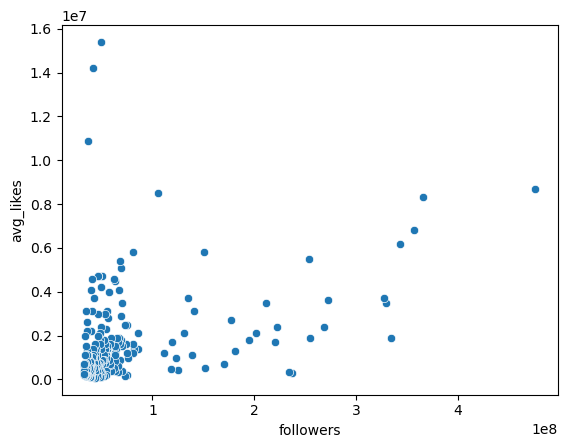

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="followers", y="avg_likes", data=df)
plt.show()

In [8]:
from scipy.stats import pearsonr

corr, p = pearsonr(df["followers"], df["avg_likes"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.34919526320577216
P-value: 4.023233692991462e-07


### Interpretation of Results

There is a moderate positive correlation (0.349) between the number of followers and the average number of likes.

The p-value is extremely small (p < 0.05), which indicates that this relationship is statistically significant.

This means that as the number of followers increases, the average number of likes also tends to increase.

However, since the correlation is not very high, follower count alone is not sufficient to fully explain engagement. Other factors may also influence engagement levels.